# Australian Apparel Sales Report - Q4 2020
## 1.Project Scope

**Project Scope:**  
To Analyse sales data from the last three months of 2020. We need to find out which Australian states make the most profit and create simple marketing plans for the states that making less profit.


Collecting scipy
  Downloading scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
Requirement already satisfied: numpy<2.7,>=1.26.4 in /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages (from scipy) (2.4.4)
Downloading scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 2.7 MB/s  0:00:07m0:00:0100:01
Installing collected packages: scipy
Successfully installed scipy-1.17.1

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

## Python Libraries Setup

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Data Wrangling (Cleaning up the Data)

### Checking for Missing Info
We use the isna()` and `notna()` methods to scan the csv

### How to fix missing data
* **Text Columns (State or Group):** If only a few rows are empty (less than 1%), it is easiest to just delete them. It keeps our financial numbers clean.
if a lot are missing, we can type in "Unknown" so we don't throw away useful data.

* **Money Columns (Sales or Units):** If numbers are missing, we should fill them using the middle number (**Median**) instead of the average. Clothing sales usually have massive spikes during holiday seasons. If we use the average, those big spikes will pull the number up too high and give us the wrong picture.


In [11]:
# Load the dataset
df = pd.read_csv('AusApparalSales4thQrt2020.csv')
print("\n\n dataset head \n\n", df.head())

print("=== PROGRAMMATIC INTEGRITY REPORT (isna) ===")
print(df.isna().sum())

print("\n=== PROGRAMMATIC VALIDITY REPORT (notna) ===")
print(df.notna().sum())

# Execute chosen data cleaning treatment: drop null configurations to protect financial audits
df = df.dropna()

# Standardize values and strip trailing white spaces
df['Time'] = df['Time'].str.strip()
df['State'] = df['State'].str.strip()
df['Group'] = df['Group'].str.strip()

# Convert chronological strings to standard datetime format
df['Date'] = pd.to_datetime(df['Date'])



 dataset head 

          Date        Time State     Group  Unit  Sales
0  1-Oct-2020     Morning    WA      Kids     8  20000
1  1-Oct-2020     Morning    WA       Men     8  20000
2  1-Oct-2020     Morning    WA     Women     4  10000
3  1-Oct-2020     Morning    WA   Seniors    15  37500
4  1-Oct-2020   Afternoon    WA      Kids     3   7500
=== PROGRAMMATIC INTEGRITY REPORT (isna) ===
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

=== PROGRAMMATIC VALIDITY REPORT (notna) ===
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64


### Choosing a Scaling Method (Normalization), Min-Max Normalization here. This scales all our sales numbers down to a simple range between 0 and 1. This makes it easy to compare different states fairly. Otherwise, big cities with lots of people would always look better

In [ ]:
# Execute Min-Max Normalization on target financial arrays
df['Normalized_Sales'] = (df['Sales'] - df['Sales'].min()) / (df['Sales'].max() - df['Sales'].min())

# Chronological Parameter Engineering for Timeline Aggregations
df['Day'] = df['Date']
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)

# Map categorical shift markers into fixed operational timeline indices for tracking peaks
time_map = {'Morning': 9, 'Afternoon': 14, 'Evening': 18, 'Night': 22}
df['Hour'] = df['Time'].map(time_map)

print("Engineered DataFrame Snapshot:")
print(df[['Date', 'State', 'Group', 'Sales', 'Normalized_Sales', 'Hour']].head())


Engineered DataFrame Snapshot:
        Date State    Group  Sales  Normalized_Sales  Hour
0 2020-10-01    WA     Kids  20000          0.095238     9
1 2020-10-01    WA      Men  20000          0.095238     9
2 2020-10-01    WA    Women  10000          0.031746     9
3 2020-10-01    WA  Seniors  37500          0.206349     9
4 2020-10-01    WA     Kids   7500          0.015873    14


In [13]:
# Data Wrangling
# 1a. Check for missing values and drop nulls to safeguard absolute financial auditing accuracy

print("\n\n Missing values per column:\n\n", df.isna().sum())

# 1b. Removing the missing rows to cleanup the data.
df = df.dropna()

# Standardize text constraints and parse datetimes
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = df['Time'].str.strip()

# Numeric hour mapping array for Time-of-the-day analysis
time_map = {'Morning': 9, 'Afternoon': 14, 'Evening': 18, 'Night': 22}
df['Hour'] = df['Time'].map(time_map)

# Time features for Dashboard Aggregations (Daily, Weekly, Monthly, Quarterly)

df['Day'] = df['Date'] 
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)


# 1c. Normalization (Scaling Sales between 0 and 1)
# Which will allows us to compare states regardless of their population size
df['Normalized_Sales'] = (df['Sales'] - df['Sales'].min()) / (df['Sales'].max() - df['Sales'].min())

# 1d. GroupBy Analysis
# Aggregating sales by State and Demographic Group
state_sales = df.groupby('State')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
group_sales = df.groupby('Group')['Sales'].sum().reset_index()

print("\n\n --- Data Wrangling Complete. --- \n\n")



 Missing values per column:

 Date                0
Time                0
State               0
Group               0
Unit                0
Sales               0
Normalized_Sales    0
Day                 0
Week                0
Month               0
Quarter             0
Hour                0
dtype: int64


 --- Data Wrangling Complete. --- 




## 2. Analyzing the Data

### Finding Averages and Patterns
We will use Python to find the standard averages, the most common sales amounts, and check how much our sales numbers fluctuate from day to day.

In [17]:
print("=== DESCRIPTIVE METRICS PROFILE ===")
summary_stats = df[['Sales', 'Unit']].describe()
print(summary_stats)

print("\n=== CALCULATED METRIC VARIANCE ===")
print(f"Sales Standard Deviation: {df['Sales'].std():,.2f}")
print(f"Unit Volume Standard Deviation: {df['Unit'].std():,.2f}")

# Extract statistical mode configurations via SciPy
sales_mode = stats.mode(df['Sales'], keepdims=True)
unit_mode = stats.mode(df['Unit'], keepdims=True)
print(f"\nStatistical Mode Value for Sales: ${sales_mode.mode[0]:,.2f} (Frequency: {sales_mode.count[0]})")
print(f"Statistical Mode Value for Units: {unit_mode.mode[0]} units (Frequency: {unit_mode.count[0]})")

# Isolating Regional Revenue Metrics
state_aggregation = df.groupby('State')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
highest_state = state_aggregation.iloc[0]
lowest_state = state_aggregation.iloc[-1]

# Isolating Consumer Demographic Profiles
demographic_aggregation = df.groupby('Group')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
highest_group = demographic_aggregation.iloc[0]
lowest_group = demographic_aggregation.iloc[-1]

print("\n=== CONSOLIDATED REGIONAL PERFORMANCE ===")
print(f"Top Revenue-Generating State Hub: {highest_state['State']} (${highest_state['Sales']:,.2f})")
print(f"Lowest Revenue-Generating State Hub: {lowest_state['State']} (${lowest_state['Sales']:,.2f})")

print("\n=== CONSOLIDATED DEMOGRAPHIC TARGETS ===")
print(f"Highest Performing Consumer Demography: {highest_group['Group']} (${highest_group['Sales']:,.2f})")
print(f"Lowest Performing Consumer Demography: {lowest_group['Group']} (${lowest_group['Sales']:,.2f})")


=== DESCRIPTIVE METRICS PROFILE ===
               Sales         Unit
count    7560.000000  7560.000000
mean    45013.558201    18.005423
std     32253.506944    12.901403
min      5000.000000     2.000000
25%     20000.000000     8.000000
50%     35000.000000    14.000000
75%     65000.000000    26.000000
max    162500.000000    65.000000

=== CALCULATED METRIC VARIANCE ===
Sales Standard Deviation: 32,253.51
Unit Volume Standard Deviation: 12.90

Statistical Mode Value for Sales: $22,500.00 (Frequency: 406)
Statistical Mode Value for Units: 9 units (Frequency: 406)

=== CONSOLIDATED REGIONAL PERFORMANCE ===
Top Revenue-Generating State Hub: VIC ($105,565,000.00)
Lowest Revenue-Generating State Hub: WA ($22,152,500.00)

=== CONSOLIDATED DEMOGRAPHIC TARGETS ===
Highest Performing Consumer Demography: Men ($85,750,000.00)
Lowest Performing Consumer Demography: Seniors ($84,037,500.00)


### Breaking Data Down by Time
We will group the sales data into weekly, monthly, and quarterly chunks to see exactly when our sales went up or down during the three months.


In [22]:
# Construct isolated time-indexed series structures
time_indexed_df = df.set_index('Date')
print("=== TIMELINE SUBSIDIARY REPORTS GENERATION ===")

# 1. Weekly Performance Accumulation Report
weekly_report = time_indexed_df.resample('W')[['Sales', 'Unit']].sum()
print(f"\nWeekly Aggregate Extrapolations (First 3 Weeks):\n{weekly_report.head(3)}")

# 2. Monthly Performance Balance Sheet Report
monthly_report = time_indexed_df.resample('ME')[['Sales', 'Unit']].sum()
print(f"\nMonthly Consolidated Balance Summary:\n{monthly_report}")

# 3. Quarterly Performance Summary Matrix
quarterly_report = time_indexed_df.resample('QE')[['Sales', 'Unit']].sum()
print(f"\nQuarterly Operating Performance Totals:\n{quarterly_report}")

# 3. Yearly Performance Summary Matrix
yearly_report = time_indexed_df.resample('YE')[['Sales', 'Unit']].sum()
print(f"\Yearly Operating Performance Totals:\n{yearly_report}")


=== TIMELINE SUBSIDIARY REPORTS GENERATION ===

Weekly Aggregate Extrapolations (First 3 Weeks):
               Sales   Unit
Date                       
2020-10-04  15045000   6018
2020-10-11  27002500  10801
2020-10-18  26640000  10656

Monthly Consolidated Balance Summary:
                Sales   Unit
Date                        
2020-10-31  114290000  45716
2020-11-30   90682500  36273
2020-12-31  135330000  54132

Quarterly Operating Performance Totals:
                Sales    Unit
Date                         
2020-12-31  340302500  136121
\Yearly Operating Performance Totals:
                Sales    Unit
Date                         
2020-12-31  340302500  136121


## 3. Building the Visual Dashboards

### Why Use Seaborn?
**Seaborn** library is used here instead of standard Matplotlib because it does a lot of the heavy grouping work for us. It lets us color-code and split our charts into categories with very little code, making it much quicker to build the final dashboards.

### What the Charts Show:
1. **State Sales by Age Group:** Shows how much money each state made, broken down by who bought the clothes.
2. **Age Group Sales by State:** Swaps the view to show customer types across all the different states.
3. **Time of Day Analysis:** Shows when people shop the most (Morning, Afternoon, Evening, or Night).
4. **Sales Spread (Box Plot):** This required chart shows the middle sales values and points out any unusual, massive single orders.
5. **Sales Curve (Distribution Plot):** This required chart shows how our everyday transaction sizes are spread out.
6. **Timeline Charts:** Shows our sales trends day-by-day, week-by-week, and month-by-month so we can see when business peaks.

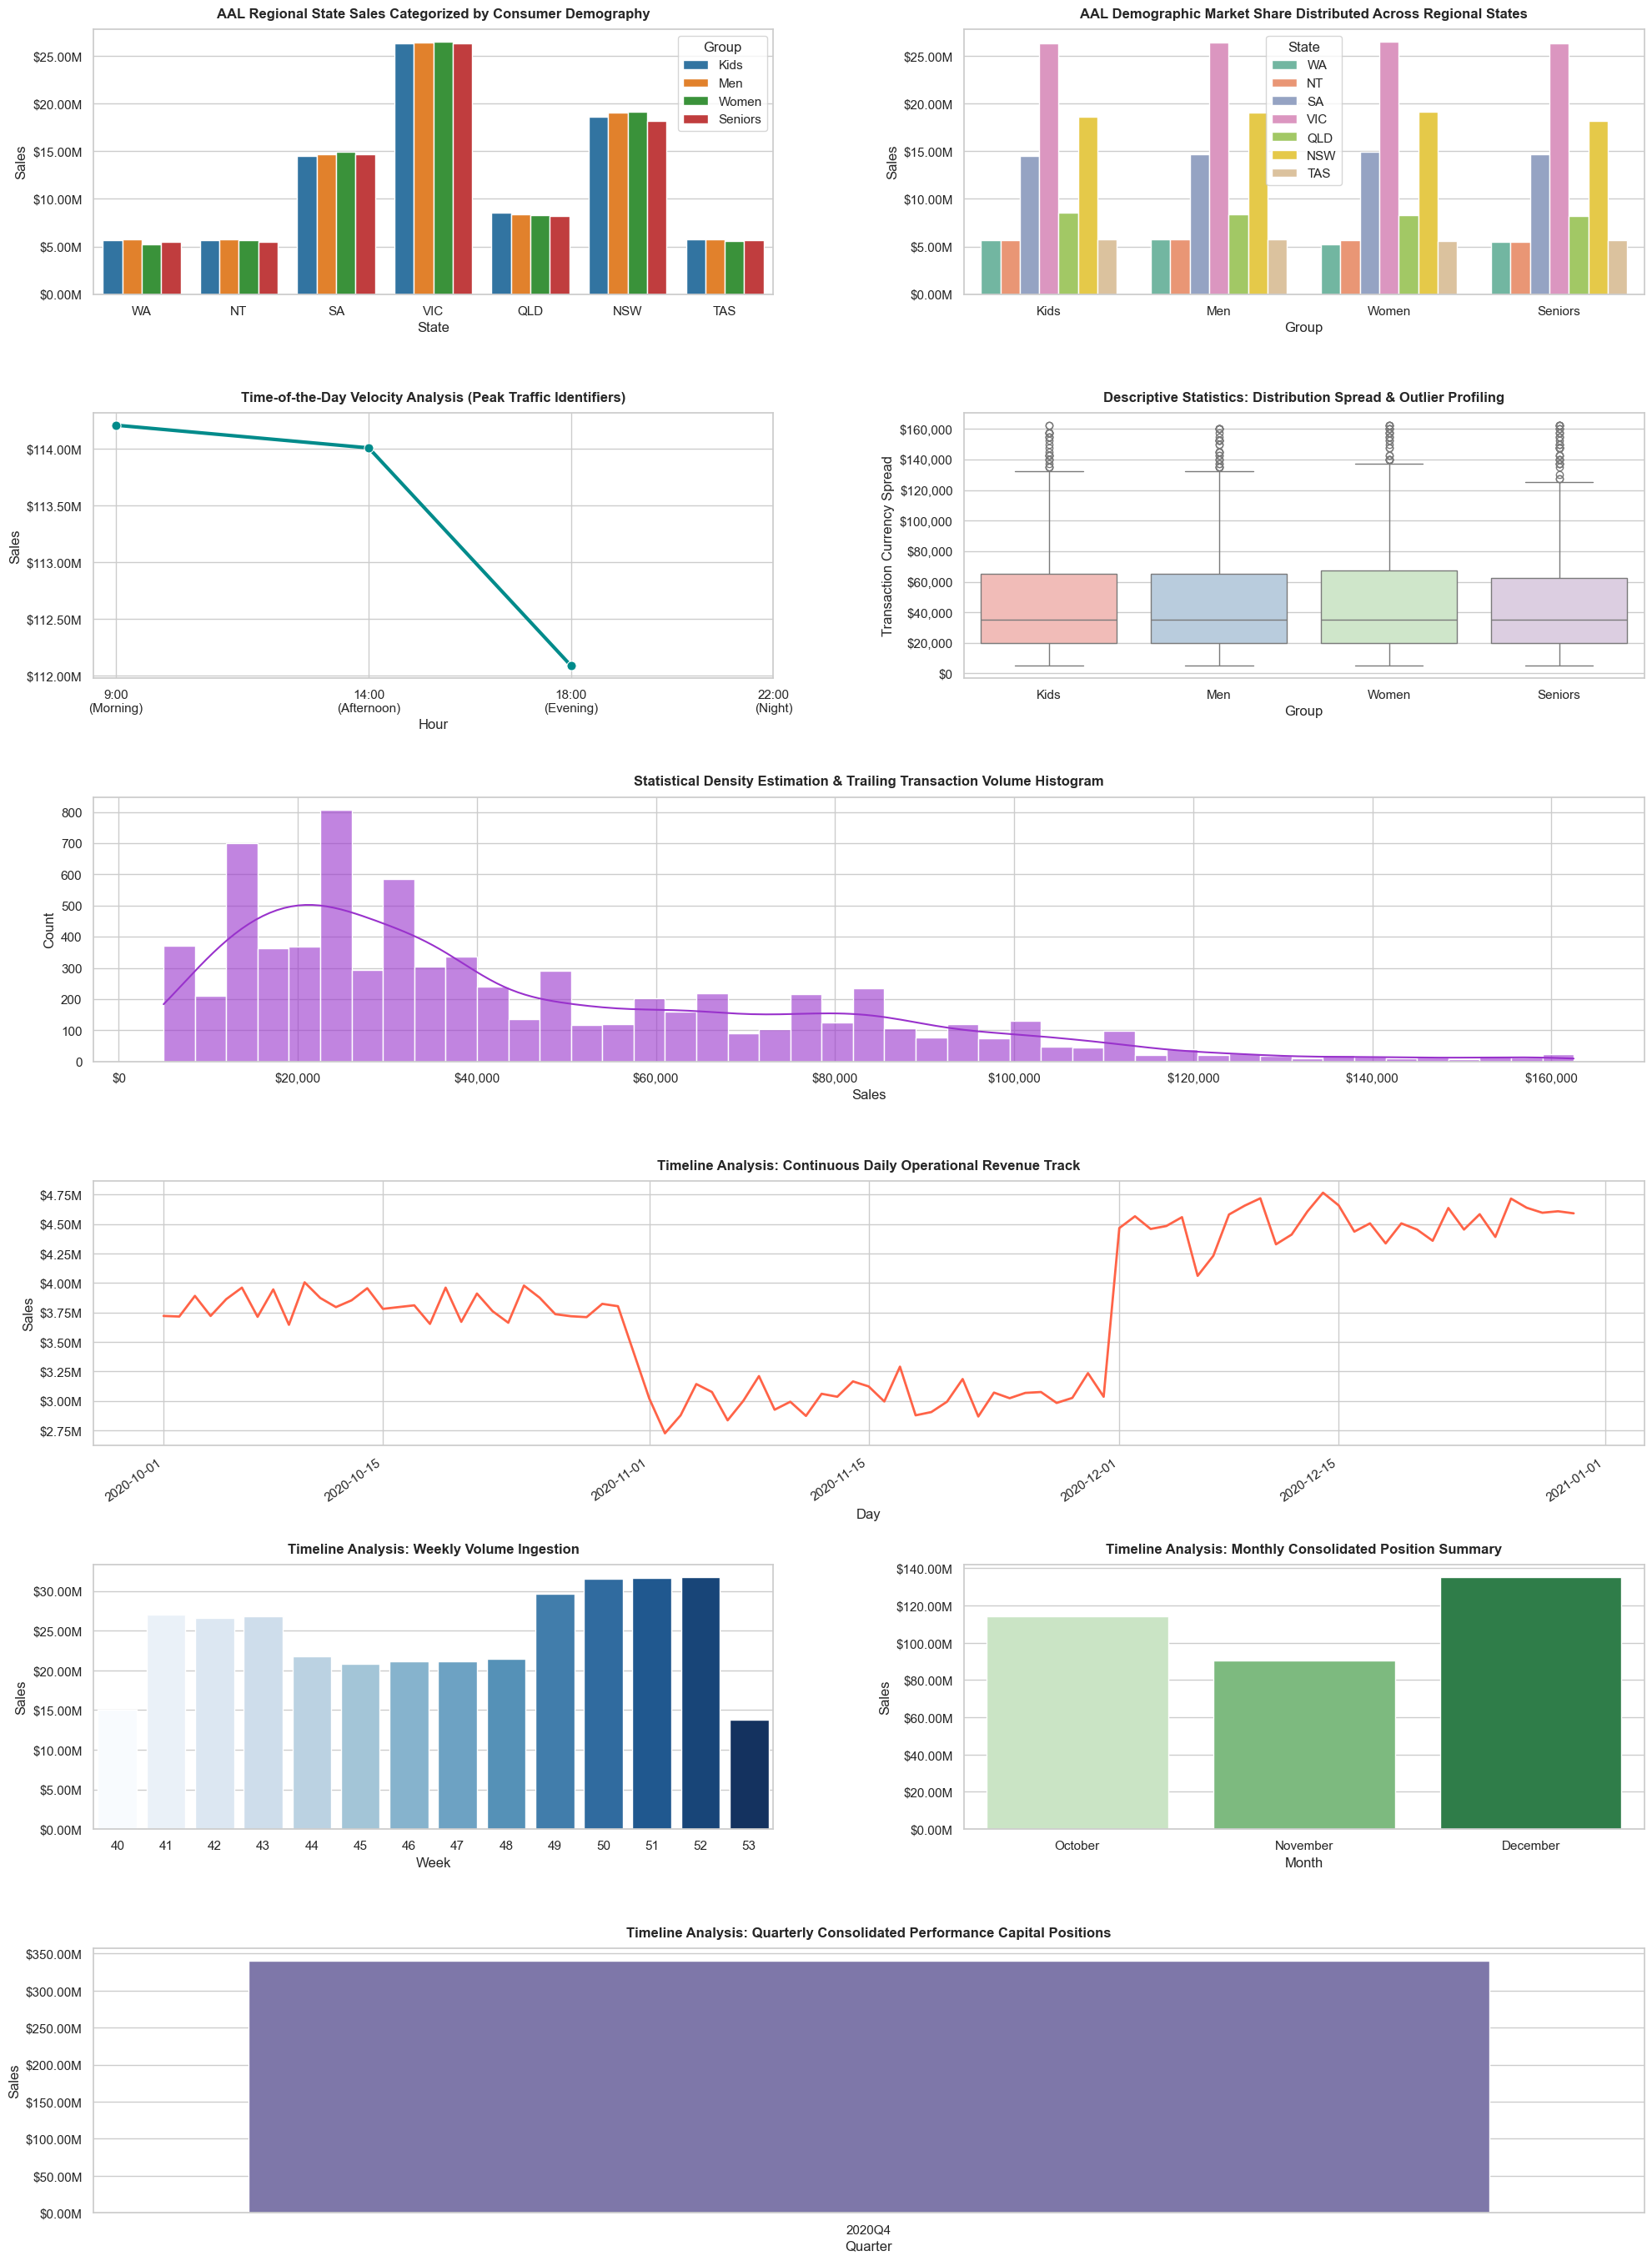

In [28]:
# Initialize layout framework
fig = plt.figure(figsize=(24, 34))
grid_spec = fig.add_gridspec(6, 2, hspace=0.45, wspace=0.28)
currency_formatter = ticker.FuncFormatter(lambda val, pos: f'${val*1e-6:,.2f}M')

# Subplot 1: State-wise Sales Analysis for Demographic Groups
ax1 = fig.add_subplot(grid_spec[0, 0])
sns.barplot(data=df, x='State', y='Sales', hue='Group', estimator=sum, errorbar=None, ax=ax1, palette='tab10')
ax1.set_title('AAL Regional State Sales Categorized by Consumer Demography', fontsize=12, fontweight='bold', pad=10)
ax1.yaxis.set_major_formatter(currency_formatter)

# Subplot 2: Group-wise Sales Analysis Across Various States
ax2 = fig.add_subplot(grid_spec[0, 1])
sns.barplot(data=df, x='Group', y='Sales', hue='State', estimator=sum, errorbar=None, ax=ax2, palette='Set2')
ax2.set_title('AAL Demographic Market Share Distributed Across Regional States', fontsize=12, fontweight='bold', pad=10)
ax2.yaxis.set_major_formatter(currency_formatter)

# Subplot 3: Operational Time-of-the-Day Velocity Plot
ax3 = fig.add_subplot(grid_spec[1, 0])
hourly_profile = df.groupby('Hour')['Sales'].sum().reset_index()
sns.lineplot(data=hourly_profile, x='Hour', y='Sales', marker='o', ax=ax3, color='darkcyan', linewidth=3, markersize=8)
ax3.set_title('Time-of-the-Day Velocity Analysis (Peak Traffic Identifiers)', fontsize=12, fontweight='bold', pad=10)
ax3.set_xticks([9, 14, 18, 22])
ax3.set_xticklabels(['9:00\n(Morning)', '14:00\n(Afternoon)', '18:00\n(Evening)', '22:00\n(Night)'])
ax3.yaxis.set_major_formatter(currency_formatter)

# Subplot 4: Mandatory Box Plot for Descriptive Statistics
ax4 = fig.add_subplot(grid_spec[1, 1])
sns.boxplot(data=df, x='Group', y='Sales', hue='Group', palette='Pastel1', ax=ax4, legend=False)
ax4.set_title('Descriptive Statistics: Distribution Spread & Outlier Profiling', fontsize=12, fontweight='bold', pad=10)
ax4.set_ylabel('Transaction Currency Spread')
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'${val:,.0f}'))

# Subplot 5: Mandatory Seaborn Distribution Plot
ax5 = fig.add_subplot(grid_spec[2, :])
sns.histplot(data=df, x='Sales', kde=True, ax=ax5, color='darkorchid', bins=45, alpha=0.6)
ax5.set_title('Statistical Density Estimation & Trailing Transaction Volume Histogram', fontsize=12, fontweight='bold', pad=10)
ax5.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'${val:,.0f}'))

# Subplot 6: Timeline Analysis - Daily Historical Trajectory
ax6 = fig.add_subplot(grid_spec[3, :])
daily_profile = df.groupby('Day')['Sales'].sum().reset_index()
sns.lineplot(data=daily_profile, x='Day', y='Sales', ax=ax6, color='tomato', linewidth=2)
ax6.set_title('Timeline Analysis: Continuous Daily Operational Revenue Track', fontsize=12, fontweight='bold', pad=10)
ax6.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax6.get_xticklabels(), rotation=35, ha='right')
ax6.yaxis.set_major_formatter(currency_formatter)

# Subplot 7: Timeline Analysis - Weekly Aggregated Volume
ax7 = fig.add_subplot(grid_spec[4, 0])
weekly_profile = df.groupby('Week')['Sales'].sum().reset_index()
sns.barplot(data=weekly_profile, x='Week', y='Sales', hue='Week', palette='Blues', ax=ax7, legend=False)
ax7.set_title('Timeline Analysis: Weekly Volume Ingestion', fontsize=12, fontweight='bold', pad=10)
ax7.yaxis.set_major_formatter(currency_formatter)

# Subplot 8: Timeline Analysis - Monthly Volume Breakdown
ax8 = fig.add_subplot(grid_spec[4, 1])
month_sort_order = ['October', 'November', 'December']
active_months = [m for m in month_sort_order if m in df['Month'].values]
monthly_profile = df.groupby('Month')['Sales'].sum().reindex(active_months).reset_index()
sns.barplot(data=monthly_profile, x='Month', y='Sales', hue='Month', palette='Greens', ax=ax8, legend=False)
ax8.set_title('Timeline Analysis: Monthly Consolidated Position Summary', fontsize=12, fontweight='bold', pad=10)
ax8.yaxis.set_major_formatter(currency_formatter)

# Subplot 9: Timeline Analysis - Consolidated Quarterly Revenue
ax9 = fig.add_subplot(grid_spec[5, :])
quarterly_profile = df.groupby('Quarter')['Sales'].sum().reset_index()
sns.barplot(data=quarterly_profile, x='Quarter', y='Sales', hue='Quarter', palette='Purples_d', ax=ax9, legend=False)
ax9.set_title('Timeline Analysis: Quarterly Consolidated Performance Capital Positions', fontsize=12, fontweight='bold', pad=10)
ax9.yaxis.set_major_formatter(currency_formatter)

plt.show()

## 4. Final Summary and Next Steps

### What We Learned From the Charts
1. **Best States to Focus On:** The states that make the most money are our top business drivers. When we decide to expand and build new flagship stores, we should put them in the major cities of these high-revenue states.
2. **Best Times for Marketing:** The line plot shows clear shopping spikes during the day. Our marketing team should time phone alerts and email ads to blast out right before these busy hours to catch customers when they are most likely to shop.

---

### Simple Marketing Plans for the Lower-Revenue States

#### Plan 1: Time Your Ads Better
* **What to do:** Send out text messages and email discount codes to customers in slower states right before our busiest local hours hit.
* **How it helps:** This reminds people to shop right when our data shows customers are most active, helping to boost sales in those quiet regions.

#### Plan 2: Offer Package Deals at Checkout
* **What to do:** Set up the cash registers in underperforming states to offer automatic bundle deals when people pay.
* **How it helps:** If a customer is buying a popular item (like regular adult clothing), the register can instantly offer a discount on a slower-moving line (like Kids' clothes). This helps clear out old stock and gets people to spend a little more money per visit.
